In [1]:
import random
import timeit
import matplotlib.pyplot as plt

In [2]:
def LinearSearch (arr, key, l, r):
    found = []
    for i in range(len(arr)):
        if arr[i] == key:
            found.append(i)
    return found


In [3]:
def BinarySearch(arr, key, l, r):
    found = []
    if l <= r:
        m = (l + r) // 2

        if arr[m] == key:
            return BinarySearch(arr, key, m + 1, r) + [m] + BinarySearch(arr, key, l, m-1)
        elif arr[m] < key:
            BinarySearch(arr, key, m + 1, r)
        else:
            BinarySearch(arr, key, l, m-1)

    return sorted(found)

# 1 5 5 5 8 10 11
# m = 3
arr = [1, 5, 8 ,5, 10, 11, 5]
arr.sort()
b = BinarySearch(arr, 5, 0, 6)
print(b)

[3, 2, 1]


In [4]:
def h(x, lenn):
    return x % lenn

def createHashTable(arr):
    lenn = len(arr)
    table = {}
    for i in arr:
        hashed = h(i, lenn)
        if hashed not in table:
            table[hashed] = i
        
        else:
            for j in range(1, lenn):
                rh = (hashed+j)%lenn
                if rh not in table:
                    table[rh] = i
                    break
    return table

def hashSearch(hashedTable, key):

    lenn=len(hashedTable)
    hashed=h(key,lenn)

    if hashed in hashedTable:
        return hashedTable[hashed]
    else: return []


In [5]:
def checkSearch(n, key, func):
    arr = [random.randint(0, key) for _ in range (n)]
    arr.sort()

    if func is hashSearch:
        table=createHashTable(arr)
        start=timeit.default_timer()
        result=func(table,key)
        end=timeit.default_timer()

    else:
        start = timeit.default_timer()
        result = func(arr, key, 0, len(arr)-1)
        end = timeit.default_timer()

    return (result, arr, (end-start)*1e6)


In [6]:
def plotGraph(func):
    l, t = [], []
    for i in range(1, 10000, 1000):
        _, _, ttime = checkSearch(i, 99, func)
        l.append(i)
        t.append(ttime)

    plt.plot(l, t, label=func.__name__)


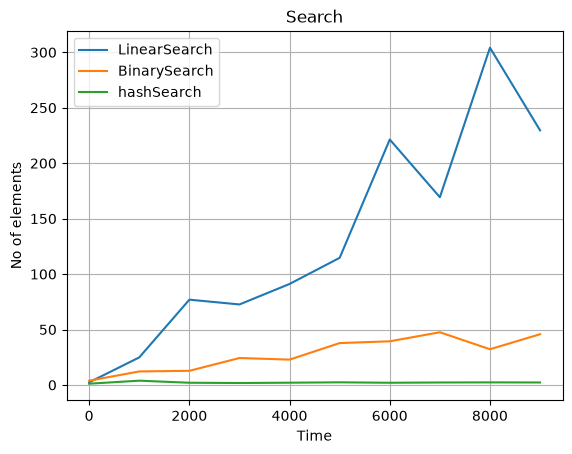

In [7]:
plotGraph(LinearSearch)
plotGraph(BinarySearch)
plotGraph(hashSearch)

plt.title("Search")
plt.xlabel("Time")
plt.ylabel("No of elements")
plt.grid()
plt.legend()
